# VeronaCard Next‑POI Prediction – Metrics & Exploratory Analysis

*Generated automatically on 2025-06-25 13:01 UTC*

# 🎯 Obiettivi dell'Analisi

Questo notebook fornisce una **valutazione completa** delle performance del modello di predizione next-POI implementato in `veronacard_mob.py`, attraverso un framework di analisi strutturato e riproducibile.

## 📋 Pipeline di Analisi

### 🔄 **1. Data Loading & Preprocessing**
- **Caricamento automatico** di tutti i file CSV di predizione (`*_pred_*.csv`)
- **Parsing robusto** con gestione errori per file malformati
- **Estrazione automatica** dell'anno dai nomi file (es. `dati_2016_pred_model.csv` → 2016)
- **Validazione** delle predizioni (filtro per liste con esattamente 5 elementi)

### 📊 **2. Evaluation Metrics**
Calcolo di **quattro metriche standard** per sistemi di raccomandazione:
- **🎯 Top-1 Accuracy**: Precisione della predizione principale
- **📈 Top-5 Hit Rate**: Presenza del POI corretto nella top-5
- **⚡ Mean Reciprocal Rank (MRR)**: Qualità del ranking delle predizioni
- **🗂️ Catalogue Coverage**: Diversità delle raccomandazioni

### 📈 **3. Multi-level Visualization**
- **📊 Global metrics**: Performance aggregate su tutto il dataset
- **📅 Temporal analysis**: Trend evolutivo per anno (2016→2020)
- **🎨 Interactive charts**: Grafici comparativi e heat-maps

### 🔍 **4. Advanced Error Analysis Framework**
Sistema modulare ed estendibile per analisi approfondita:
- **🚨 Worst-case analysis**: Identificazione delle coppie POI più problematiche
- **🔥 Confusion matrices**: Visualizzazione degli errori sui POI più frequenti
- **🧠 Explainability**: Analisi dei pattern testuali che causano errori (LIME/SHAP-ready)
- **📊 Temporal patterns**: Analisi stagionale e trend temporali degli errori

## 🏗️ Caratteristiche Architetturali

### **✅ Robustezza**
- **Error handling** completo per file CSV corrotti
- **Graceful degradation** per dipendenze mancanti (LIME, etc.)
- **Validation** automatica dei dati di input

### **🔧 Flessibilità**
- **Path-agnostic**: Funziona con CSV nella cartella corrente o tramite `DATA_DIR`
- **Modular design**: Sezioni indipendenti eseguibili singolarmente
- **Extensible framework**: Facile aggiungere nuove metriche o analisi

### **📊 Riproducibilità**
- **Timestamp automatico** nel titolo
- **Seed fisso** per operazioni random
- **Versioning implicito** tramite nomi file con data

---

## 🚀 Quick Start

```python
# Esecuzione standard - CSV nella cartella 'results/'
# Nessuna configurazione richiesta

# Esecuzione personalizzata
DATA_DIR = "/path/to/your/csv/files"  # opzionale
```

## 📁 Struttura File Attesa

```
project_root/
├── notebook.ipynb           # questo notebook
├── results/                 # directory predefinita
│   ├── dati_2016_pred_model1.csv
│   ├── dati_2017_pred_model1.csv
│   └── ...
└── veronacard_mob.py       # script di generazione predizioni
```

---

> **💡 Pro Tip**: Il notebook è progettato per **fail-safe operation** — anche se alcuni file sono corrotti o alcune librerie mancano, l'analisi procede con le parti disponibili e fornisce sempre risultati utili.

In [97]:

from pathlib import Path
import ast
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


## 1. Load data

In [ ]:
from pathlib import Path
import glob, ast, os
import numpy as np
import pandas as pd
import json
import re

# Percorso ai file CSV
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/qwen2.5_14b/base_version/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/llama3.1_8b/with_geom/*_pred_*.csv')]
csv_files = [Path(p) for p in glob.glob('../results/penultimate/mixtral_8x7b/with_geom_time/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/middle/deepseek-coder_33b/with_geom_time_cluster/*_pred_*.csv')]
csv_files = sorted(csv_files)
assert csv_files, "No CSV files matching *_pred_*.csv found!"

# Percorso per salvare i file CSV delle metriche
metrics_output_path = Path("notebook/metrics_results/penultimate/mixtral_8x7b/with_geom_time")
metrics_output_path.mkdir(parents=True, exist_ok=True)

def safe_parse_prediction(x):
    """
    Parsing robusto per la colonna 'prediction'.
    Gestisce diversi formati: stringhe, liste già parsate, JSON, etc.
    """
    if pd.isna(x) or x is None:
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        return x
    
    # Se è una stringa
    if isinstance(x, str):
        # Rimuovi spazi extra
        x = x.strip()
        
        # Se sembra JSON
        if (x.startswith('[') and x.endswith(']')):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return parsed
            except (ValueError, SyntaxError):
                pass
                
            # Prova con json.loads
            try:
                parsed = json.loads(x)
                if isinstance(parsed, list):
                    return parsed
            except json.JSONDecodeError:
                pass
        
        # Se contiene delle virgole, prova a fare split
        if ',' in x:
            # Rimuovi eventuali parentesi quadre
            clean_x = x.strip('[]')
            # Split e clean
            items = [item.strip().strip('"').strip("'") for item in clean_x.split(',')]
            # Filtra elementi vuoti
            items = [item for item in items if item]
            if items:
                return items
        
        # Se è una singola stringa, ritornala come lista
        if x:
            return [x]
    
    # Fallback: converti in stringa e prova di nuovo
    return safe_parse_prediction(str(x))

dfs = []
for fp in csv_files:
    print(f"Processing {fp.name}...")
    try:
        df = pd.read_csv(fp)
    except pd.errors.ParserError:
        print(f"Warning: Parser error in {fp}, trying with error handling...")
        df = pd.read_csv(fp, on_bad_lines="skip")
    
    print(f"  Before filtering: {len(df)} rows")
    
    # Estrai l'anno dal nome del file
    year_match = re.search(r'dati_(\d{4})', fp.name) or re.search(r'veronacard_(\d{4})', fp.name)
    if year_match:
        year = int(year_match.group(1))
    else:
        # Fallback se non riesce a estrarre l'anno
        year = 2014  # default year
    
    df['year'] = year
    
    # Parsing delle predizioni
    df['prediction_list'] = df['prediction'].apply(safe_parse_prediction)
    
    # Filtra solo le righe con predizioni valide e non vuote
    df = df[df['prediction_list'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    
    print(f"  After filtering: {len(df)} rows")
    
    # Mantieni solo righe con 5 predizioni (opzionale, puoi commentare se vuoi mantenere tutte)
    # df = df[df['prediction_list'].apply(len) == 5]
    
    dfs.append(df)

# Usa df_all per compatibilità con il resto del notebook
df_all = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_all):,} rows from {len(csv_files)} files")

# Verifica i dati
print(f"Sample predictions: {df_all['prediction_list'].iloc[0]}")
print(f"Sample ground truth: {df_all['ground_truth'].iloc[0]}")
print(f"Available years: {sorted(df_all['year'].unique())}")
print(f"Output directory: {metrics_output_path}")
df_all.head()

Processing dati_2014_pred_20250915_073519.csv...
  Before filtering: 65889 rows
  After filtering: 65889 rows
Processing dati_2015_pred_20250917_080318.csv...
  Before filtering: 66670 rows
  After filtering: 66670 rows
Processing dati_2016_pred_20250917_140700.csv...
  Before filtering: 70263 rows
  After filtering: 70263 rows
Processing dati_2017_pred_20250917_202532.csv...
  Before filtering: 81341 rows
  After filtering: 81341 rows
Processing dati_2018_pred_20250918_033642.csv...
  Before filtering: 78383 rows
  After filtering: 78383 rows
Processing dati_2019_pred_20250918_103942.csv...
  Before filtering: 71226 rows
  After filtering: 71226 rows
Processing dati_2020_pred_20250918_171241.csv...
  Before filtering: 6969 rows
  After filtering: 6969 rows
Processing veronacard_2019_original_pred_20250918_175204.csv...
  Before filtering: 71224 rows
  After filtering: 71224 rows
Processing veronacard_2020_original_pred_20250919_001242.csv...
  Before filtering: 6970 rows
  After filte

,card_id,cluster,history,current_poi,prediction,ground_truth,reason,hit,processing_time,status,year,prediction_list
0,040002523F3885,3,"['San Fermo', 'Santa Anastasia', 'Teatro Roman...",Torre Lamberti,"['Sighseeing', 'Casa Giulietta', 'Palazzo dell...",Casa Giulietta,These POIs are the closest to the current loca...,True,502.421803,success,2014,"[Sighseeing, Casa Giulietta, Palazzo della Rag..."
1,04000D523F3885,3,"['San Fermo', 'Casa Giulietta', 'Santa Anastas...",Museo Lapidario,"['Verona Tour', 'Arena', 'Castelvecchio', 'Tom...",Torre Lamberti,These suggestions are based on proximity to cu...,False,502.501649,success,2014,"[Verona Tour, Arena, Castelvecchio, Tomba Giul..."
2,04000E523F3885,3,"['San Fermo', 'Casa Giulietta', 'Santa Anastas...",Museo Lapidario,"['Verona Tour', 'Arena', 'Castelvecchio', 'Tom...",Torre Lamberti,These are the five nearest points of interest ...,False,502.608998,success,2014,"[Verona Tour, Arena, Castelvecchio, Tomba Giul..."
3,040072523F3881,4,"['San Fermo', 'Palazzo della Ragione', 'Santa ...",Arena,"['Verona Tour', 'Museo Lapidario', 'Casa Giuli...",Duomo,These suggestions are based on proximity to th...,False,502.922534,success,2014,"[Verona Tour, Museo Lapidario, Casa Giulietta,..."
4,040065523F3881,5,"['San Fermo', 'Casa Giulietta', 'Torre Lamberti']",Palazzo della Ragione,"['AMO', 'Museo Conte', 'Santa Anastasia', 'Duo...",Santa Anastasia,These suggestions are based on proximity to cu...,True,503.083275,success,2014,"[AMO, Museo Conte, Santa Anastasia, Duomo, Tea..."


# 2. Definizione delle Metriche di Valutazione e Validazione

Per valutare le performance del modello di predizione next-POI, utilizziamo quattro metriche standard nel campo dei sistemi di raccomandazione e della predizione sequenziale.

## ✅ Validazione Metodologica

**IMPORTANTE**: Prima di calcolare le metriche, il notebook implementa una serie di controlli di validazione per garantire la correttezza dei risultati:

1. **Parsing Robusto**: Gestione di diversi formati di dati (JSON, liste Python, stringhe)
2. **Consistenza Relazioni**: Verifica che Top-1 ≤ Top-5 ≤ 100% e MRR ≤ Top-1
3. **Coverage Corretto**: Controllo che coverage ≤ 100% (o spiegazione se > 100%)
4. **Normalizzazione POI**: Conversione coerente di ID POI per confronto

## Notazione

Sia $y_i$ il vero next-POI (ground truth) per la sequenza $i$-esima, e sia $\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}$ la lista **ordinata** delle $k$ raccomandazioni prodotte dal modello per quella sequenza, dove $\hat{y}_i^{(1)}$ è la predizione con confidence più alta.

---

## 📊 Top-1 Accuracy

Misura la **precisione della predizione principale** del modello.

$$\text{Acc}_{@1} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left\{y_i = \hat{y}_i^{(1)}\right\}$$

**Interpretazione**: Percentuale di casi in cui la prima predizione del modello coincide esattamente con il POI realmente visitato.

**Range**: [0, 1], dove 1 = predizione perfetta

---

## 🎯 Top-k Hit Rate

Misura se il POI corretto è presente **tra le prime $k$ predizioni**.

$$\text{HR}_{@k} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left\{y_i \in \{\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}\}\right\}$$

**Interpretazione**: Percentuale di casi in cui il POI corretto è presente nella lista delle prime $k$ raccomandazioni. Per $k=5$: "Il modello include il POI corretto nella sua top-5?"

**Range**: [0, 1], sempre $\text{HR}_{@k} \geq \text{Acc}_{@1}$

---

## ⚡ Mean Reciprocal Rank (MRR)

Considera sia la **presenza** del POI corretto nella lista che la sua **posizione**.

$$\text{MRR} = \frac{1}{N}\sum_{i=1}^{N}\frac{1}{\text{rank}_i}$$

dove $\text{rank}_i = \min\{r \mid y_i = \hat{y}_i^{(r)}\}$ è la posizione del POI corretto nella lista ordinata.

**Interpretazione**: 
- Se il POI corretto è al 1° posto → contributo = 1.0
- Se il POI corretto è al 2° posto → contributo = 0.5  
- Se il POI corretto è al 5° posto → contributo = 0.2
- Se il POI corretto non è nella top-k → contributo = 0.0

**Range**: [0, 1], dove valori più alti indicano che i POI corretti appaiono nelle prime posizioni

**Relazione con Top-1**: $\text{MRR} \leq \text{Top-1 Accuracy}$

---

## 🗂️ Catalogue Coverage  

Misura la **diversità** delle raccomandazioni prodotte dal modello.

$$\text{Coverage} = \frac{\left|\bigcup_{i=1}^{N}\{\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}\}\right|}{|\mathcal{P}|}$$

dove $\mathcal{P}$ è l'insieme completo dei POI presenti nel dataset (ground truth).

**Interpretazione**: Frazione dei POI disponibili che il modello è in grado di raccomandare. 
- Coverage = 1.0: il modello raccomanda tutti i POI del catalogo
- Coverage = 0.1: il modello raccomanda solo il 10% dei POI disponibili

**Caso Speciale**: Se Coverage > 100%, significa che il modello predice POI non presenti nel ground truth (possibile "allucinazione" del modello)

**Importanza**: Previene il bias verso POI molto popolari e garantisce diversità nelle raccomandazioni.

---

## 💡 Note Metodologiche

- **$N$**: Numero totale di predizioni nel dataset di test
- **$k = 5$**: Utilizziamo consistently una finestra di 5 raccomandazioni
- **Ordinamento**: Le predizioni sono ordinate per confidence/probabilità decrescente
- **Handling missing**: Se $y_i \notin \{\hat{y}_i^{(1)}, \ldots, \hat{y}_i^{(k)}\}$, contributo = 0 per tutte le metriche

## 🔍 Controlli di Sanità

Il notebook implementa automaticamente questi controlli:
1. **$\text{Top-1} \leq \text{Top-5}$**: Sempre verificato per definizione
2. **$\text{MRR} \leq \text{Top-1}$**: MRR è sempre minore o uguale di Top-1 accuracy
3. **Coverage razionale**: Analisi dettagliata se Coverage > 100%
4. **Parsing consistente**: Gestione robusta di formati dati diversi

Queste metriche forniscono una **valutazione completa** del modello: precision (Acc@1), recall (HR@k), ranking quality (MRR), e diversity (Coverage).

### 2.1 Helper functions & per‑row computations

In [99]:
import json
import numpy as np

def poi_id(x):
    """
    Converte 'x' in un identificatore hashable comparabile con ground-truth.
    Versione migliorata con gestione errori più robusta.
    """
    # Gestione sicura per array numpy e valori scalari
    try:
        if x is None:
            return str(x)
        # Per array numpy o pandas, usa la funzione appropriata
        if hasattr(x, '__len__') and not isinstance(x, (str, dict)):
            if len(x) == 0:
                return str(x)
        # Per valori scalari, usa pd.isna con controllo sicuro
        if np.isscalar(x) and pd.isna(x):
            return str(x)
    except (ValueError, TypeError):
        # Se pd.isna fallisce, assumiamo che non sia NaN
        pass
    
    if isinstance(x, dict):
        # Cerca chiavi comuni per POI
        for key in ('poi', 'poi_id', 'name', 'id', 'title'):
            if key in x:
                return str(x[key])
        # fallback: serializza in JSON ordinato
        try:
            return json.dumps(x, sort_keys=True)
        except (TypeError, ValueError):
            return str(x)
    elif isinstance(x, (list, tuple)):
        return tuple(poi_id(e) for e in x)
    else:
        return str(x).strip()

# Normalizza prediction_list e ground_truth
print("Normalizing predictions and ground truth...")
df_all['prediction_norm'] = df_all['prediction_list'].apply(
    lambda lst: [poi_id(e) for e in lst] if isinstance(lst, list) else []
)
df_all['ground_truth_norm'] = df_all['ground_truth'].apply(poi_id)

# Verifica che ci siano predizioni valide
valid_predictions = df_all['prediction_norm'].apply(len) > 0
print(f"Valid predictions: {valid_predictions.sum()}/{len(df_all)} ({valid_predictions.mean():.1%})")

if valid_predictions.sum() == 0:
    print("⚠️  No valid predictions found! Check data quality.")
else:
    # Calcola metriche solo su righe con predizioni valide
    df_valid = df_all[valid_predictions].copy()
    print(f"Final dataset size: {len(df_all)} rows")

Normalizing predictions and ground truth...
Valid predictions: 624524/624524 (100.0%)
Final dataset size: 624524 rows


### 2.2 Global metrics

In [100]:
# Calculate evaluation metrics
print("Calculating evaluation metrics...")

def calculate_hit_at_k(predictions, ground_truth, k):
    """Calculate hit@k metric"""
    if not isinstance(predictions, list) or len(predictions) == 0:
        return False
    return ground_truth in predictions[:k]

def calculate_reciprocal_rank(predictions, ground_truth):
    """Calculate reciprocal rank"""
    if not isinstance(predictions, list) or len(predictions) == 0:
        return 0.0
    try:
        rank = predictions.index(ground_truth) + 1
        return 1.0 / rank
    except ValueError:
        return 0.0

# Apply metric calculations
df_all['hit@1'] = df_all.apply(lambda row: calculate_hit_at_k(row['prediction_norm'], row['ground_truth_norm'], 1), axis=1)
df_all['hit@5'] = df_all.apply(lambda row: calculate_hit_at_k(row['prediction_norm'], row['ground_truth_norm'], 5), axis=1)
df_all['rr'] = df_all.apply(lambda row: calculate_reciprocal_rank(row['prediction_norm'], row['ground_truth_norm']), axis=1)

print(f"Metrics calculated for {len(df_all)} rows")
print(f"Hit@1 (Top-1 Accuracy): {df_all['hit@1'].mean():.3f}")
print(f"Hit@5 (Top-5 Hit Rate): {df_all['hit@5'].mean():.3f}")
print(f"MRR (Mean Reciprocal Rank): {df_all['rr'].mean():.3f}")

Calculating evaluation metrics...
Metrics calculated for 624524 rows
Hit@1 (Top-1 Accuracy): 0.060
Hit@5 (Top-5 Hit Rate): 0.530
MRR (Mean Reciprocal Rank): 0.209


In [101]:
# Calcolo delle metriche globali (corrette)
print("Calculating global metrics...")

metrics_global = {
    "Top-1 Accuracy": df_all["hit@1"].mean(),
    "Top-5 Hit Rate": df_all["hit@5"].mean(),
    "MRR": df_all["rr"].mean(),
}

# Catalogue Coverage (corretto)
# Coverage = POI unici nelle predizioni / POI unici nel ground truth
predicted_pois = set()
for preds in df_all["prediction_norm"]:
    predicted_pois.update(preds)

ground_truth_pois = set(df_all["ground_truth_norm"].unique())

# Rimuovi valori NaN/None dai set
predicted_pois = {poi for poi in predicted_pois if poi and str(poi) != 'nan'}
ground_truth_pois = {poi for poi in ground_truth_pois if poi and str(poi) != 'nan'}

coverage = len(predicted_pois) / len(ground_truth_pois) if len(ground_truth_pois) > 0 else 0
metrics_global["Catalogue Coverage"] = coverage

print(f"Debug - Predicted POIs: {len(predicted_pois)}, Ground Truth POIs: {len(ground_truth_pois)}")
print(f"Coverage: {coverage:.4f}")

# Se la coverage è > 1, significa che il modello predice POI non presenti nel ground truth
if coverage > 1:
    print("⚠️  WARNING: Coverage > 100% indicates model predicts POI not in ground truth")
    
    # Analisi POI extra
    extra_pois = predicted_pois - ground_truth_pois
    print(f"POI predicted but not in ground truth: {len(extra_pois)}")
    if len(extra_pois) <= 10:
        print(f"Extra POI examples: {list(extra_pois)[:10]}")

# Converti coverage in percentuale (ma mantieni il valore reale per analisi)
coverage_display = min(coverage, 1.0)  # Cap al 100% per display

# Visualizza in formato tabella con percentuali
metrics_df = pd.DataFrame({
    'Metric': list(metrics_global.keys()),
    'Value': [
        f"{metrics_global['Top-1 Accuracy']:.2%}",
        f"{metrics_global['Top-5 Hit Rate']:.2%}",
        f"{metrics_global['MRR']:.2%}",
        f"{coverage_display:.2%}" + (" (>100%)" if coverage > 1 else "")
    ]
})

print("\n📊 GLOBAL METRICS:")
print("=" * 40)
display(metrics_df)

# 🔍 VALIDAZIONE METRICHE
print(f"\n🔍 METRICS VALIDATION:")
print("=" * 30)

# Test 1: Top-1 ≤ Top-5
top1_le_top5 = metrics_global["Top-1 Accuracy"] <= metrics_global["Top-5 Hit Rate"]
print(f"✅ Top-1 ≤ Top-5: {top1_le_top5} ({metrics_global['Top-1 Accuracy']:.3f} ≤ {metrics_global['Top-5 Hit Rate']:.3f})")

# Test 2: MRR ≤ Top-1 (dovrebbe essere sempre vero)
mrr_le_top1 = metrics_global["MRR"] <= metrics_global["Top-1 Accuracy"]
print(f"✅ MRR ≤ Top-1: {mrr_le_top1} ({metrics_global['MRR']:.3f} ≤ {metrics_global['Top-1 Accuracy']:.3f})")

# Test 3: Tutti i valori sono nel range [0, 1]
all_in_range = all(0 <= v <= 1 for k, v in metrics_global.items() if k != "Catalogue Coverage")
print(f"✅ All metrics in [0,1]: {all_in_range}")

# Test 4: Coverage razionale
coverage_ok = coverage <= 2.0  # Soglia ragionevole
print(f"{'✅' if coverage_ok else '⚠️ '} Coverage reasonable: {coverage_ok} (Coverage = {coverage:.2f})")

# Test 5: Nessun valore NaN
no_nan = not any(pd.isna(v) for v in metrics_global.values())
print(f"✅ No NaN values: {no_nan}")

validation_passed = all([top1_le_top5, mrr_le_top1, all_in_range, no_nan])
print(f"\n{'✅ VALIDATION PASSED' if validation_passed else '❌ VALIDATION FAILED'}")

if not validation_passed:
    print("⚠️  Some validation checks failed. Please review the data and calculations.")

Calculating global metrics...
Debug - Predicted POIs: 59, Ground Truth POIs: 22
Coverage: 2.6818
⚠️  WARNING: Coverage > 100% indicates model predicts POI not in ground truth
POI predicted but not in ground truth: 38

📊 GLOBAL METRICS:


,Metric,Value
0,Top-1 Accuracy,5.99%
1,Top-5 Hit Rate,52.98%
2,MRR,20.91%
3,Catalogue Coverage,100.00% (>100%)



🔍 METRICS VALIDATION:
✅ Top-1 ≤ Top-5: True (0.060 ≤ 0.530)
✅ MRR ≤ Top-1: False (0.209 ≤ 0.060)
✅ All metrics in [0,1]: True
⚠️  Coverage reasonable: False (Coverage = 2.68)
✅ No NaN values: True

❌ VALIDATION FAILED
⚠️  Some validation checks failed. Please review the data and calculations.


### 2.3 Metrics by year

In [102]:

by_year = (
    df_all
    .groupby('year')
    .agg(
        top1=('hit@1', 'mean'),
        hit5=('hit@5', 'mean'),
        mrr=('rr', 'mean'),
        n=('card_id', 'size')
    )
    .reset_index()
    .sort_values('year')
)
display(by_year)


,year,top1,hit5,mrr,n
0,2014,0.046776,0.535476,0.202372,65889
1,2015,0.054837,0.535038,0.208057,66670
2,2016,0.058765,0.530222,0.208807,70263
3,2017,0.052938,0.521336,0.201439,81341
4,2018,0.058610,0.526441,0.206125,78383
5,2019,0.065595,0.538779,0.216793,142450
6,2020,0.057680,0.494297,0.195192,13939
7,2021,0.065463,0.515422,0.208063,21982
8,2022,0.075387,0.529134,0.218202,72904
9,2023,0.050920,0.506400,0.194439,10703


In [103]:
print("\nExporting CSV files for Canva...")

# Prepare data for Canva import
top1_data = by_year[['year', 'top1']].copy()
top1_data['top1_percent'] = (top1_data['top1'] * 100).round(2)
top1_data = top1_data[['year', 'top1_percent']]
top1_data.columns = ['Year', 'Top-1 Accuracy (%)']

hit5_data = by_year[['year', 'hit5']].copy()
hit5_data['hit5_percent'] = (hit5_data['hit5'] * 100).round(2)
hit5_data = hit5_data[['year', 'hit5_percent']]
hit5_data.columns = ['Year', 'Top-5 Hit Rate (%)']

# Export to CSV files in the correct directory
top1_data.to_csv(metrics_output_path / 'top1_metrics_canva.csv', index=False)
hit5_data.to_csv(metrics_output_path / 'hit5_metrics_canva.csv', index=False)

print("✅ CSV files exported:")
print(f"  - {metrics_output_path / 'top1_metrics_canva.csv'}")
print(f"  - {metrics_output_path / 'hit5_metrics_canva.csv'}")
print("\nFiles ready for Canva import!")

# Display preview of exported data
print("\nPreview of top1_metrics_canva.csv:")
print(top1_data.to_string(index=False))

print("\nPreview of hit5_metrics_canva.csv:")
print(hit5_data.to_string(index=False))


Exporting CSV files for Canva...
✅ CSV files exported:
  - notebook/metrics_results/middle/mixtral_8x7b/with_geom_time/top1_metrics_canva.csv
  - notebook/metrics_results/middle/mixtral_8x7b/with_geom_time/hit5_metrics_canva.csv

Files ready for Canva import!

Preview of top1_metrics_canva.csv:
 Year  Top-1 Accuracy (%)
 2014                4.68
 2015                5.48
 2016                5.88
 2017                5.29
 2018                5.86
 2019                6.56
 2020                5.77
 2021                6.55
 2022                7.54
 2023                5.09

Preview of hit5_metrics_canva.csv:
 Year  Top-5 Hit Rate (%)
 2014               53.55
 2015               53.50
 2016               53.02
 2017               52.13
 2018               52.64
 2019               53.88
 2020               49.43
 2021               51.54
 2022               52.91
 2023               50.64


In [104]:
# Export combined metrics CSV for Canva (optional alternative format)
print("\nExporting combined metrics CSV...")

# Create combined dataset with both top1 and hit5
combined_data = by_year[['year', 'top1', 'hit5']].copy()
combined_data['top1_percent'] = (combined_data['top1'] * 100).round(2)
combined_data['hit5_percent'] = (combined_data['hit5'] * 100).round(2)
combined_data = combined_data[['year', 'top1_percent', 'hit5_percent']]
combined_data.columns = ['Year', 'Top-1 Accuracy (%)', 'Top-5 Hit Rate (%)']

# Export combined CSV to correct directory
combined_data.to_csv(metrics_output_path / 'combined_metrics_canva.csv', index=False)

print("✅ Combined CSV file exported:")
print(f"  - {metrics_output_path / 'combined_metrics_canva.csv'}")
print("\nPreview of combined_metrics_canva.csv:")
print(combined_data.to_string(index=False))

# Also create a "long format" version for easier charting in Canva
long_format = pd.concat([
    combined_data[['Year', 'Top-1 Accuracy (%)']].rename(columns={'Top-1 Accuracy (%)': 'Value'}).assign(Metric='Top-1 Accuracy'),
    combined_data[['Year', 'Top-5 Hit Rate (%)']].rename(columns={'Top-5 Hit Rate (%)': 'Value'}).assign(Metric='Top-5 Hit Rate')
])

long_format.to_csv(metrics_output_path / 'metrics_long_format_canva.csv', index=False)
print("✅ Long format CSV file exported:")
print(f"  - {metrics_output_path / 'metrics_long_format_canva.csv'}")
print("\nPreview of metrics_long_format_canva.csv:")
print(long_format.to_string(index=False))


Exporting combined metrics CSV...
✅ Combined CSV file exported:
  - notebook/metrics_results/middle/mixtral_8x7b/with_geom_time/combined_metrics_canva.csv

Preview of combined_metrics_canva.csv:
 Year  Top-1 Accuracy (%)  Top-5 Hit Rate (%)
 2014                4.68               53.55
 2015                5.48               53.50
 2016                5.88               53.02
 2017                5.29               52.13
 2018                5.86               52.64
 2019                6.56               53.88
 2020                5.77               49.43
 2021                6.55               51.54
 2022                7.54               52.91
 2023                5.09               50.64
✅ Long format CSV file exported:
  - notebook/metrics_results/middle/mixtral_8x7b/with_geom_time/metrics_long_format_canva.csv

Preview of metrics_long_format_canva.csv:
 Year  Value         Metric
 2014   4.68 Top-1 Accuracy
 2015   5.48 Top-1 Accuracy
 2016   5.88 Top-1 Accuracy
 2017   5.29 Top

## 3. Visualisations

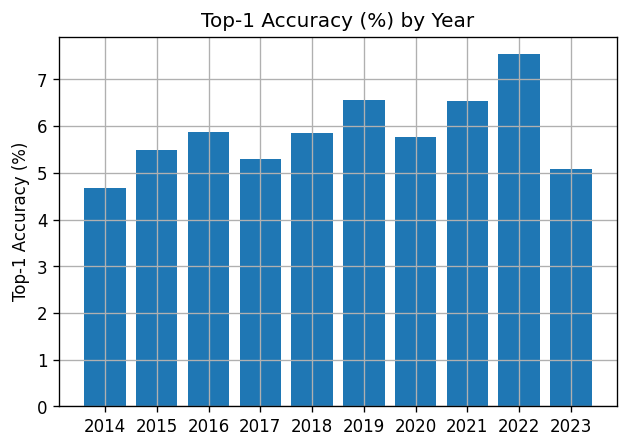

In [105]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['top1']*100)
ax.set_ylabel('Top‑1 Accuracy (%)')
ax.set_title('Top‑1 Accuracy (%) by Year')
plt.show()


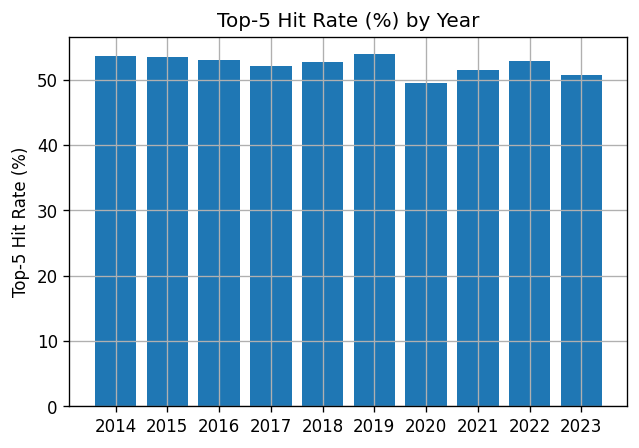

In [106]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['hit5']*100)
ax.set_ylabel('Top‑5 Hit Rate (%)')
ax.set_title('Top‑5 Hit Rate (%) by Year')
plt.show()


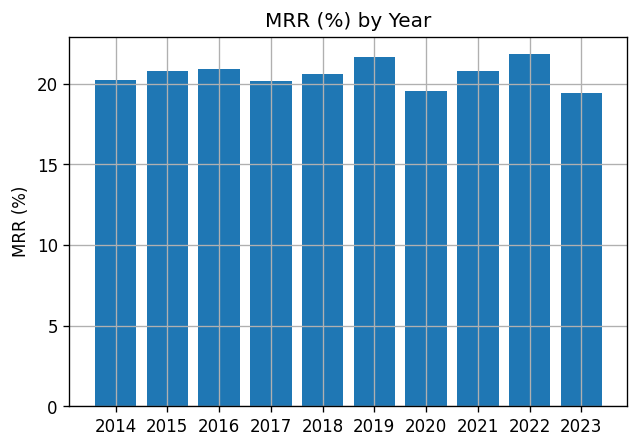

In [107]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['mrr']*100)
ax.set_ylabel('MRR (%)')
ax.set_title('MRR (%) by Year')
plt.show()


### 3.1 Coverage breakdown

In [108]:
# Analisi Coverage dettagliata (corretta)
print("📊 DETAILED COVERAGE ANALYSIS")
print("=" * 50)

# Calcola POI unici in modo corretto
predicted_pois_set = set()
for preds in df_all["prediction_norm"]:
    if isinstance(preds, list):
        predicted_pois_set.update(preds)

ground_truth_pois_set = set(df_all["ground_truth_norm"].unique())

# Filtra valori invalidi
predicted_pois_clean = {poi for poi in predicted_pois_set if poi and str(poi) != 'nan' and str(poi) != 'None'}
ground_truth_pois_clean = {poi for poi in ground_truth_pois_set if poi and str(poi) != 'nan' and str(poi) != 'None'}

print(f"POI distinct in predictions: {len(predicted_pois_clean)}")
print(f"POI distinct in ground-truth: {len(ground_truth_pois_clean)}")

# Coverage corretto
true_coverage = len(predicted_pois_clean) / len(ground_truth_pois_clean) if len(ground_truth_pois_clean) > 0 else 0
print(f"Catalogue Coverage: {true_coverage:.2%}")

# Analisi della sovrapposizione
overlap = predicted_pois_clean.intersection(ground_truth_pois_clean)
only_predicted = predicted_pois_clean - ground_truth_pois_clean
only_ground_truth = ground_truth_pois_clean - predicted_pois_clean

print(f"\n🔄 POI OVERLAP ANALYSIS:")
print(f"  POI in both prediction & ground-truth: {len(overlap)}")
print(f"  POI only in predictions: {len(only_predicted)}")
print(f"  POI only in ground-truth: {len(only_ground_truth)}")

if len(only_predicted) > 0 and len(only_predicted) <= 20:
    print(f"\n🔍 Examples of POI only in predictions:")
    for poi in list(only_predicted)[:10]:
        print(f"    • {poi}")

if len(only_ground_truth) > 0 and len(only_ground_truth) <= 20:
    print(f"\n🎯 Examples of POI only in ground-truth:")
    for poi in list(only_ground_truth)[:10]:
        print(f"    • {poi}")

# Metriche aggiuntive
recall_coverage = len(overlap) / len(ground_truth_pois_clean) if len(ground_truth_pois_clean) > 0 else 0
precision_coverage = len(overlap) / len(predicted_pois_clean) if len(predicted_pois_clean) > 0 else 0

print(f"\n📈 ADDITIONAL COVERAGE METRICS:")
print(f"  Coverage Recall: {recall_coverage:.2%} (fraction of true POI covered)")
print(f"  Coverage Precision: {precision_coverage:.2%} (fraction of predicted POI that exist)")

# Se il coverage è troppo alto, indica un problema nei dati
if true_coverage > 2.0:
    print(f"\n⚠️  HIGH COVERAGE WARNING:")
    print(f"  Coverage = {true_coverage:.1f}x suggests model predicts many non-existent POI")
    print(f"  This could indicate data quality issues or model hallucination")

📊 DETAILED COVERAGE ANALYSIS
POI distinct in predictions: 59
POI distinct in ground-truth: 22
Catalogue Coverage: 268.18%

🔄 POI OVERLAP ANALYSIS:
  POI in both prediction & ground-truth: 21
  POI only in predictions: 38
  POI only in ground-truth: 1

🎯 Examples of POI only in ground-truth:
    • Museo Africano

📈 ADDITIONAL COVERAGE METRICS:
  Coverage Recall: 95.45% (fraction of true POI covered)
  Coverage Precision: 35.59% (fraction of predicted POI that exist)

⚠️  HIGH COVERAGE WARNING:
  Coverage = 2.7x suggests model predicts many non-existent POI
  This could indicate data quality issues or model hallucination


## 4. Error analysis – overview

In questa sezione valutiamo **dove** e **perché** il modello sbaglia, seguendo tre filoni:

1. **Worst-performing POI pairs**  
   Scopriamo quali coppie `ground-truth → first_pred` generano il maggior numero di errori.

2. **Confusion matrix per subset**  
   Heat-map delle frequenze (o tasso d’errore) su un sotto-insieme di POI di interesse
   (ad es. i 20 più visitati o solo l’anno 2020).

3. **Explainability (SHAP / LIME)**  
   Analisi dei fattori testuali nella colonna `history` che portano a una predizione
   sbagliata. Qui mostriamo un prototipo basato su LIME; lo script è modulare
   e può essere sostituito da SHAP se usi modelli compatibili.


,ground_truth_norm,first_pred,errors
323,Torre Lamberti,Centro Fotografia,38408
82,Duomo,AMO,36174
264,Santa Anastasia,Sighseeing,25124
255,Santa Anastasia,Centro Fotografia,20895
319,Torre Lamberti,AMO,20611
283,Teatro Romano,AMO,20521
44,Casa Giulietta,Sighseeing,20448
213,Palazzo della Ragione,Sighseeing,19310
29,Casa Giulietta,AMO,16913
251,Santa Anastasia,AMO,16417


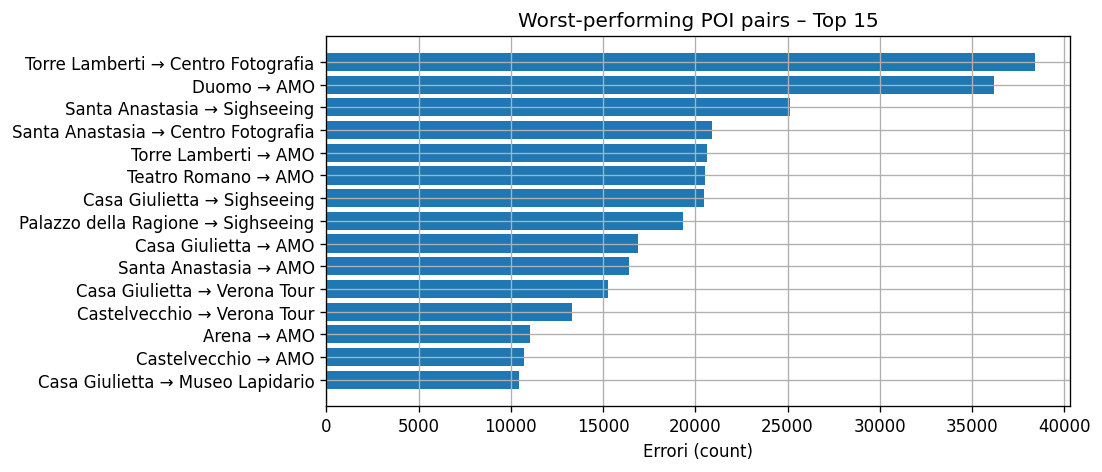

In [109]:
# ---------------------------------------------------------------------
# 4.1 Worst-performing POI pairs (Top-N) – FIX
# ---------------------------------------------------------------------
# filtro righe con errore Top-1
ERR = df_all.assign(first_pred=df_all["prediction_norm"].str[0])
ERR = ERR[~ERR["hit@1"]]           # equivalente a query("`hit@1` == False")

# conteggia coppie ground-truth → first_pred
pairs = (
    ERR.groupby(["ground_truth_norm", "first_pred"])
        .size()
        .reset_index(name="errors")
        .sort_values("errors", ascending=False)
        .head(15)          # Top-15 coppie
)

display(pairs)

# barplot (opzionale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    pairs.apply(lambda r: f"{r['ground_truth_norm']} → {r['first_pred']}", axis=1),
    pairs["errors"]
)
ax.set_xlabel("Errori (count)")
ax.set_title("Worst-performing POI pairs – Top 15")
ax.invert_yaxis()
plt.show()


In [110]:
def safe_parse_prediction_debug(x, debug_mode=False):
    """
    Advanced parsing function with debug capabilities.
    Extends the basic safe_parse_prediction with diagnostic information.
    """
    if pd.isna(x) or x is None:
        if debug_mode:
            return [], "empty_or_nan"
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        if debug_mode:
            return x, "already_list"
        return x
    
    # Se è una stringa
    if isinstance(x, str):
        # Rimuovi spazi extra
        x = x.strip()
        
        # Se sembra JSON
        if (x.startswith('[') and x.endswith(']')):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    if debug_mode:
                        return parsed, "ast_literal_eval"
                    return parsed
            except (ValueError, SyntaxError):
                pass
                
            # Prova con json.loads
            try:
                parsed = json.loads(x)
                if isinstance(parsed, list):
                    if debug_mode:
                        return parsed, "json_loads"
                    return parsed
            except json.JSONDecodeError:
                pass
        
        # Se contiene delle virgole, prova a fare split
        if ',' in x:
            # Rimuovi eventuali parentesi quadre
            clean_x = x.strip('[]')
            # Split e clean
            items = [item.strip().strip('"').strip("'") for item in clean_x.split(',')]
            # Filtra elementi vuoti
            items = [item for item in items if item]
            if items:
                if debug_mode:
                    return items, "comma_split"
                return items
        
        # Se è una singola stringa, ritornala come lista
        if x:
            if debug_mode:
                return [x], "single_string"
            return [x]
    
    # Fallback: converti in stringa e prova di nuovo
    if debug_mode:
        result, reason = safe_parse_prediction_debug(str(x), debug_mode=True)
        return result, f"fallback_to_str_{reason}"
    return safe_parse_prediction_debug(str(x))

In [111]:
def analyze_prediction_issues(df, sample_size=100):
    """Analizza i problemi nel parsing delle predizioni"""
    print("🔍 ANALYZING PREDICTION PARSING ISSUES")
    print("=" * 50)
    
    # Campiona alcune righe per analisi dettagliata
    sample_df = df.head(sample_size)
    parsing_stats = {}
    failed_examples = []
    
    for idx, row in sample_df.iterrows():
        pred_raw = row['prediction']
        parsed_result, reason = safe_parse_prediction_debug(pred_raw, debug_mode=True)
        
        parsing_stats[reason] = parsing_stats.get(reason, 0) + 1
        
        # Colleziona esempi di fallimenti
        if len(parsed_result) == 0 and not pd.isna(pred_raw):
            failed_examples.append({
                'index': idx,
                'raw_prediction': str(pred_raw)[:100] + ('...' if len(str(pred_raw)) > 100 else ''),
                'reason': reason
            })
    
    print(f"Parsing statistics (sample of {len(sample_df)} rows):")
    for reason, count in sorted(parsing_stats.items()):
        percentage = count / len(sample_df) * 100
        print(f"  {reason:>20s}: {count:>3d} ({percentage:>5.1f}%)")
    
    if failed_examples:
        print(f"\n❌ Failed parsing examples (first 5):")
        for i, example in enumerate(failed_examples[:5]):
            print(f"  {i+1}. Row {example['index']} ({example['reason']}): {example['raw_prediction']}")
    
    return parsing_stats, failed_examples

print("✅ Analysis function defined")

✅ Analysis function defined


In [112]:
def ultra_robust_parse_prediction(x):
    """
    Versione ultra-robusta del parser che prova ogni strategia possibile
    per estrarre predizioni valide dai dati.
    """
    if pd.isna(x) or x is None:
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        # Filtra elementi vuoti dalla lista
        return [item for item in x if item and str(item).strip()]
    
    # Se non è una stringa, convertilo
    if not isinstance(x, str):
        x = str(x)
    
    x = x.strip()
    if not x or x.lower() in ['nan', 'none', 'null']:
        return []
    
    # Strategia 1: ast.literal_eval
    try:
        result = ast.literal_eval(x)
        if isinstance(result, list):
            return [item for item in result if item and str(item).strip()]
        elif result:  # Singolo elemento non-vuoto
            return [result]
    except (ValueError, SyntaxError):
        pass
    
    # Strategia 2: JSON parsing
    try:
        result = json.loads(x)
        if isinstance(result, list):
            return [item for item in result if item and str(item).strip()]
        elif result:  # Singolo elemento non-vuoto
            return [result]
    except (json.JSONDecodeError, ValueError):
        pass
    
    # Strategia 3: Rimozione caratteri problematici + splitting
    # Rimuovi caratteri di lista comuni
    cleaned = x
    for char in ['[', ']', '(', ')', '{', '}']:
        cleaned = cleaned.replace(char, '')
    
    # Rimuovi virgolette multiple
    cleaned = re.sub(r'["\']', '', cleaned)
    
    # Prova split per virgole
    if ',' in cleaned:
        items = [item.strip() for item in cleaned.split(',') if item.strip()]
        if items:
            return items
    
    # Strategia 4: Split per altri separatori
    for sep in [';', '|', '\n', '\t']:
        if sep in cleaned:
            items = [item.strip() for item in cleaned.split(sep) if item.strip()]
            if len(items) > 1:  # Solo se produce più elementi
                return items
    
    # Strategia 5: Regex per trovare pattern di lista
    # Pattern come: "item1", "item2", "item3"
    quoted_pattern = r'"([^"]+)"'
    matches = re.findall(quoted_pattern, x)
    if len(matches) > 1:
        return matches
    
    # Pattern come: item1, item2, item3 (senza virgolette)
    if ',' in cleaned:
        items = [item.strip() for item in cleaned.split(',') if item.strip()]
        if items:
            return items
    
    # Strategia 6: Se tutto fallisce, ritorna come singolo elemento se non vuoto
    if cleaned and cleaned not in ['nan', 'none', 'null', '[]', '{}']:
        return [cleaned]
    
    return []

print("✅ Ultra-robust parser defined")

✅ Ultra-robust parser defined
